In [1]:
import os, sys
sys.path.insert(0, '../XenonStandaloneDisplay')

In [2]:
from bokeh.io import show, output_notebook
import PMT as pmt
import pandas as pd

In [3]:
a = pmt.Display('Log')
a.showPMT()

In [4]:
import os
import math
import zstd
import time
import pickle
from textwrap import dedent
from datetime import datetime

import multihist
import numpy as np
import pandas as pd
Rtpc=664.
Reff=664.
delta_x=10.
delta_y=5.
imax = int(np.ceil(Rtpc/delta_x))
jmax = int(np.ceil((Rtpc/delta_y)-(1./2.)))
def load_map(map_file):
    with open(map_file, mode='rb') as f:
        data = pickle.load(f)    
    # Decompress / dequantize the map
    if 'compressed' in data:
        compressor, dtype, shape = data['compressed']
        if compressor == "zstd":
            data['map'] = np.frombuffer(zstd.decompress(data['map']), dtype=dtype).reshape(*shape)
            del data['compressed']
    if 'quantized' in data:
        data['map'] = data['quantized'] * data['map'].astype(np.float32)
        del data['quantized']

    if "rotated" in data:
        print("rotated")
    
    # Add a mask for bins without any events
    
    data['map'] = np.ma.masked_where(condition=(data['map'] == 0), a=data['map'])

     
    hist = multihist.Histdd(dimensions=[(ax, np.linspace(left-((right - left)/(points - 1)/2), right+((right - left)/(points - 1)/2), points+1)) for ax, (left, right, points) in data['coordinate_system']] + 
                                       [('pmthitID', np.arange(-0.5, data['map'].shape[2]))])
    hist.histogram = data['map']
    return hist

---> TefRef0.8.pkl
rotated


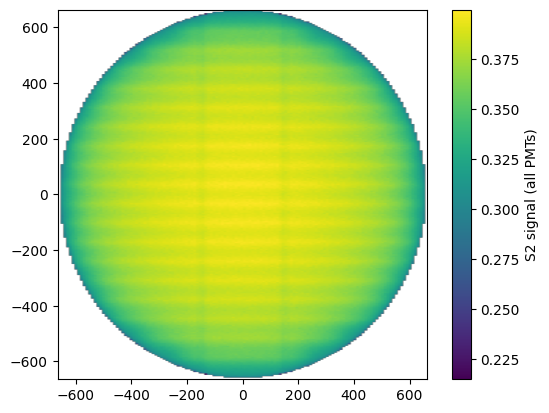

---> TefRef0.84.pkl
rotated


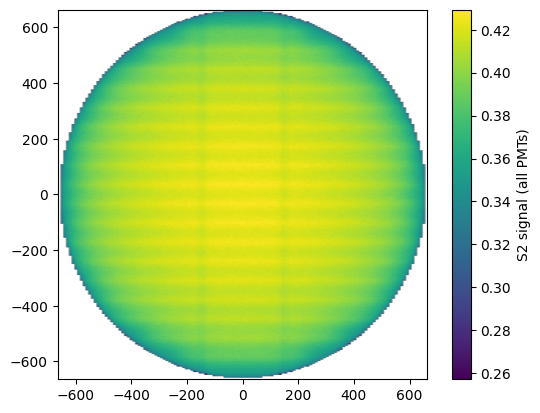

---> TefRef0.88.pkl
rotated


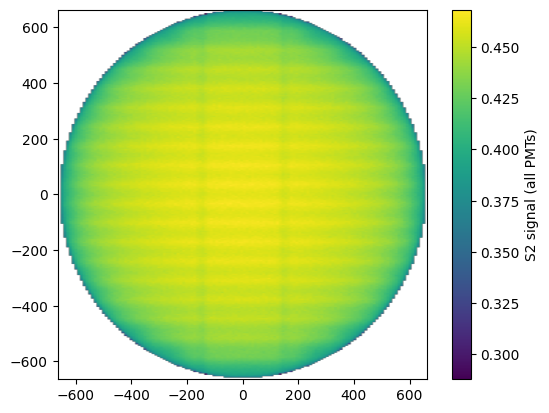

---> TefRef0.92.pkl
rotated


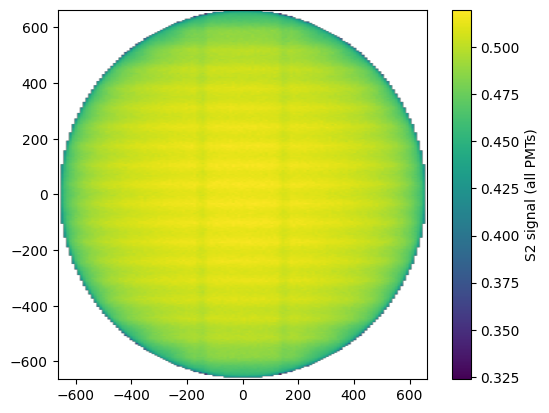

---> TefRef0.96.pkl
rotated


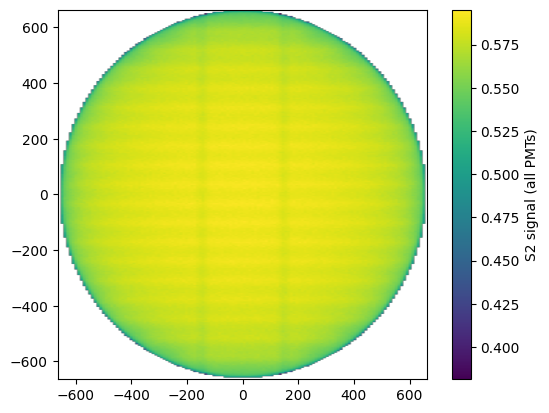

---> TefRef1.0.pkl
rotated


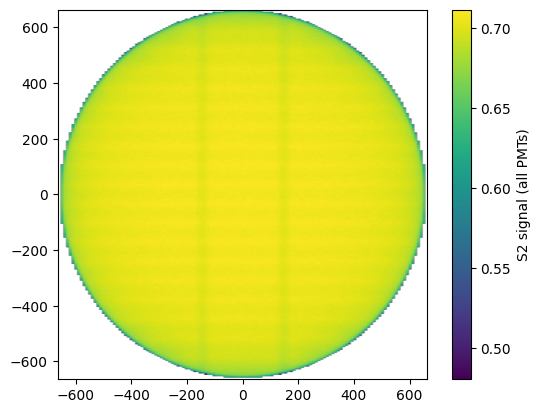

In [5]:
import matplotlib.pyplot as plt
#map_file = ['GXeWR0.7.pkl']#,'GXeWR0.3.pkl','GXeWR0.5.pkl','GXeWR0.7.pkl','GXeWR0.9.pkl']
map_file =['TefRef0.8.pkl','TefRef0.84.pkl','TefRef0.88.pkl','TefRef0.92.pkl','TefRef0.96.pkl','TefRef1.0.pkl']

for i in map_file:
    print('--->',i)
    i = 'scans/'+i
    histall = load_map(i)
    histall = histall.histogram.sum(axis=2)
    plt.imshow(histall.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='viridis')
    plt.colorbar(label="S2 signal (all PMTs)")
    plt.show()

In [65]:
histall = load_map('scans/GXeWR0.7.pkl')
hist_per_pmt = histall.histogram.sum(axis=(0, 1))  # Shape = (nb_pmts,)

rotated


rotated
scans/TefRef0.8.pkl Mean 20.679817971912957 Mean Top  31.159880264945652 Mean bottom 9.677930903137966 AFT 0.7716896
rotated
scans/TefRef0.84.pkl Mean 22.424595141700404 Mean Top  32.673828125 Mean bottom 11.665030958246888 AFT 0.7462236
rotated
scans/TefRef0.88.pkl Mean 24.69469967737854 Mean Top  34.549237277667984 Mean bottom 14.349481733013485 AFT 0.71651995
rotated
scans/TefRef0.92.pkl Mean 27.779304782388664 Mean Top  36.97166038784585 Mean bottom 18.129240550440873 AFT 0.68161815
rotated
scans/TefRef0.96.pkl Mean 32.21953876201923 Mean Top  40.28727921195652 Mean bottom 23.750085094657678 AFT 0.6403865
rotated
scans/TefRef1.0.pkl Mean 39.17183546305668 Mean Top  45.23263417119565 Mean bottom 32.80925627269191 AFT 0.5913867


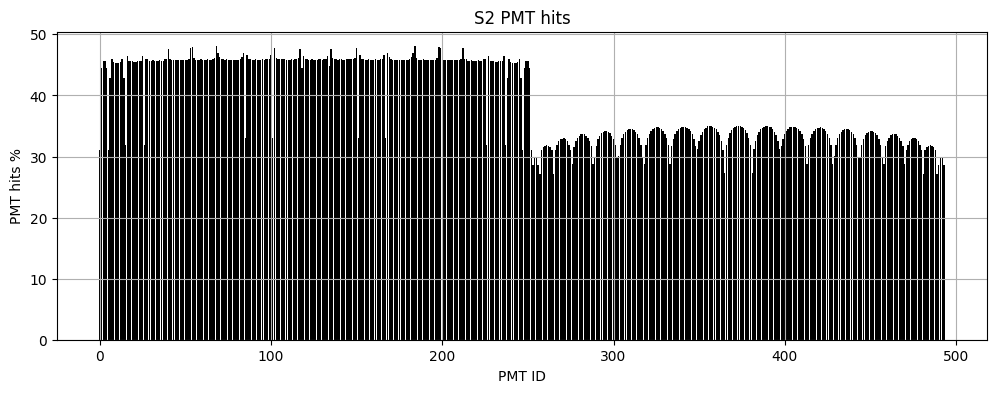

In [6]:
#map_file = ['GXeWR0.1.pkl','GXeWR0.3.pkl','GXeWR0.5.pkl','GXeWR0.7.pkl','GXeWR0.9.pkl']
map_file =['TefRef0.8.pkl','TefRef0.84.pkl','TefRef0.88.pkl','TefRef0.92.pkl','TefRef0.96.pkl','TefRef1.0.pkl']

colors = ['green','blue','red','yellow','pink','black']
plt.figure(figsize=(12, 4))
for k,i in enumerate(map_file):
    #if k>0:
    #    break
    i='scans/'+i
    histall = load_map(i)
    hist_per_pmt = histall.histogram.sum(axis=(0, 1))  # Shape = (nb_pmts,)
    print(i,'Mean',hist_per_pmt.mean(),'Mean Top ',hist_per_pmt[:253].mean(), 'Mean bottom' ,hist_per_pmt[253:].mean(), 'AFT', 
          hist_per_pmt[:253].sum()/hist_per_pmt.sum(),)
    plt.bar(np.arange(len(hist_per_pmt)), hist_per_pmt,color=colors[k], label=i)
plt.xlabel("PMT ID")
plt.ylabel("PMT hits %")
plt.title("S2 PMT hits")
plt.grid(True)
plt.show()


rotated
./MapNewBinning/S2map_SR1.pkl Mean 22.664789979757085 Mean Top  33.944088901926875 Mean bottom 10.823866214989627 AFT 0.76701885


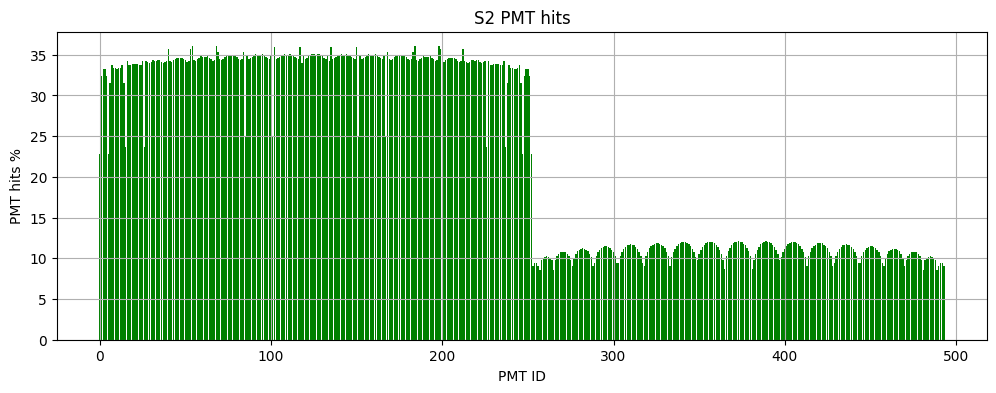

In [7]:
map_file =['./MapNewBinning/S2map_SR1.pkl']

colors = ['green','blue','red','yellow','pink','black']
plt.figure(figsize=(12, 4))
for k,i in enumerate(map_file):
    #if k>0:
    #    break
    histall = load_map(i)
    hist_per_pmt = histall.histogram.sum(axis=(0, 1))  # Shape = (nb_pmts,)
    print(i,'Mean',hist_per_pmt.mean(),'Mean Top ',hist_per_pmt[:253].mean(), 'Mean bottom' ,hist_per_pmt[253:].mean(), 'AFT', 
          hist_per_pmt[:253].sum()/hist_per_pmt.sum())
    plt.bar(np.arange(len(hist_per_pmt)), hist_per_pmt,color=colors[k], label=i)
plt.xlabel("PMT ID")
plt.ylabel("PMT hits %")
plt.title("S2 PMT hits")
plt.grid(True)
plt.show()


In [101]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

def colmap(values):
    # Exemple : valeurs pour chaque PMT
    # Normaliser les valeurs entre 0 et 1
    norm = plt.Normalize(vmin=values.min(), vmax=values.max())
    
    # Choisir une colormap (par exemple 'viridis', 'plasma', 'inferno', etc.)
    cmap = plt.cm.viridis
    
    # Appliquer la colormap et convertir en hexadécimal
    hex_colors = [matplotlib.colors.to_hex(cmap(norm(v))) for v in values]
    
    for i, (v, color) in enumerate(zip(values, hex_colors)):
        print(f"PMT {i} : valeur = {v:.3f}, couleur = {color}")
    return hex_colors

In [91]:
hist_per_pmt
display = pmt.Display()
#deadPMTs = [108, 121, 156, 164, 177, 291, 313, 350, 352, 354, 362, 386, 393, 427, 442, 461]
display.showPrecisePMT(list(range(494)),colmap(hist_per_pmt))
display.showPMT()

PMT 0 : valeur = 24.197, couleur = #218e8d
PMT 1 : valeur = 34.498, couleur = #b2dd2d
PMT 2 : valeur = 35.321, couleur = #c8e020
PMT 3 : valeur = 35.320, couleur = #c8e020
PMT 4 : valeur = 34.509, couleur = #b2dd2d
PMT 5 : valeur = 24.197, couleur = #218e8d
PMT 6 : valeur = 33.251, couleur = #90d743
PMT 7 : valeur = 35.576, couleur = #cde11d
PMT 8 : valeur = 35.361, couleur = #c8e020
PMT 9 : valeur = 35.283, couleur = #c5e021
PMT 10 : valeur = 35.266, couleur = #c5e021
PMT 11 : valeur = 35.274, couleur = #c5e021
PMT 12 : valeur = 35.364, couleur = #c8e020
PMT 13 : valeur = 35.591, couleur = #cde11d
PMT 14 : valeur = 33.260, couleur = #90d743
PMT 15 : valeur = 24.894, couleur = #1f948c
PMT 16 : valeur = 36.064, couleur = #dae319
PMT 17 : valeur = 35.548, couleur = #cde11d
PMT 18 : valeur = 35.743, couleur = #d2e21b
PMT 19 : valeur = 35.888, couleur = #d5e21a
PMT 20 : valeur = 35.839, couleur = #d5e21a
PMT 21 : valeur = 35.851, couleur = #d5e21a
PMT 22 : valeur = 35.897, couleur = #d5e21

---> GXeWR0.1.pkl
rotated


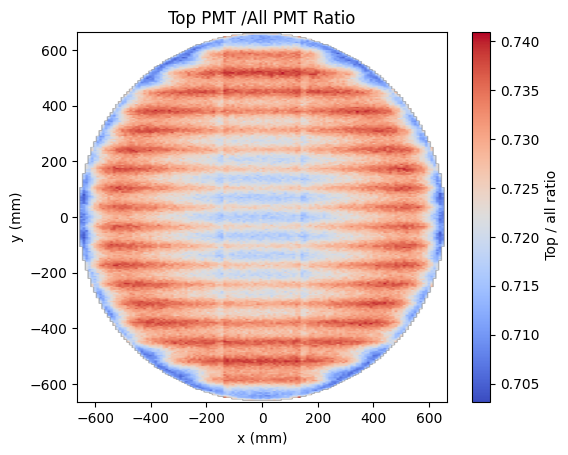

---> GXeWR0.9.pkl
rotated


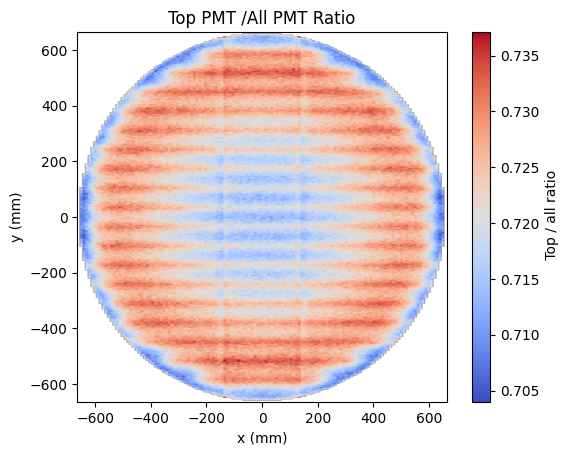

In [108]:
map_file = ['GXeWR0.1.pkl','GXeWR0.9.pkl']
#,'GXeWR0.3.pkl','GXeWR0.5.pkl','GXeWR0.7.pkl','GXeWR0.9.pkl'],'TefRef0.84.pkl','TefRef0.84.pkl','TefRef0.92.pkl','TefRef0.96.pkl',
#map_file =['TefRef0.8.pkl','TefRef1.0.pkl']
for i in map_file:
    print('--->',i)
    i = 'scans/'+i
    top_slice = slice(0, 252+1)  
    histall = load_map(i)
    hist_top = histall.histogram[:, :, top_slice].sum(axis=2)

    histall = histall.histogram.sum(axis=2)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.true_divide(hist_top,histall)
        ratio[~np.isfinite(ratio)] = 0  # remplace les inf/nan par 0
    
    
    plt.imshow(ratio.T, origin='lower', extent=[-Rtpc, Rtpc, -Rtpc, Rtpc], cmap='coolwarm')
    plt.colorbar(label=" Top / all ratio")
    plt.title("Top PMT /All PMT Ratio")
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.show()

In [ ]:
93 mm
93e6/1e6

In [57]:
ratio = ratio.filled(0) 

In [58]:
display = pmt.Display()
#deadPMTs = [108, 121, 156, 164, 177, 291, 313, 350, 352, 354, 362, 386, 393, 427, 442, 461]
display.showPrecisePMT(list(range(494)),colmap(ratio))
display.showPMT()

ValueError: RGBA sequence should have length 3 or 4

In [121]:
import numpy as np

def generate_spiral(n):
    size = int(np.ceil(np.sqrt(n)))
    if size % 2 == 0:
        size += 1
    spiral = np.zeros((size, size), dtype=int)

    x = y = size // 2
    dx, dy = 1, 0
    steps = 1
    value = 1

    while value <= n:
        for _ in range(2):
            for _ in range(steps):
                if 0 <= x < size and 0 <= y < size:
                    spiral[y, x] = value
                    value += 1
                    if value > n:
                        return spiral
                x += dx
                y += dy
            dx, dy = -dy, dx
        steps += 1
    return spiral

def get_spiral_around(spiral, target, count):
    y, x = np.argwhere(spiral == target)[0]
    coords = [(y, x)]
    dx, dy = 1, 0
    steps = 1

    while len(coords) < count:
        for _ in range(2):
            for _ in range(steps):
                x += dx
                y += dy
                if 0 <= y < spiral.shape[0] and 0 <= x < spiral.shape[1]:
                    coords.append((y, x))
                    if len(coords) >= count:
                        break
            dx, dy = -dy, dx
            if len(coords) >= count:
                break
        steps += 1

    return [spiral[y, x] for y, x in coords]

# Générer la spirale
spirale = generate_spiral(100)
print(spirale)
# Partir de 5, récupérer les 5 premiers nombres en spirale locale
resultat = get_spiral_around(spirale, target=15, count=15)
print("Spirale locale à partir de 5 :", resultat)


[[  0   0   0   0   0   0   0   0   0   0   0]
 [  0  73  74  75  76  77  78  79  80  81  82]
 [  0  72  43  44  45  46  47  48  49  50  83]
 [  0  71  42  21  22  23  24  25  26  51  84]
 [  0  70  41  20   7   8   9  10  27  52  85]
 [  0  69  40  19   6   1   2  11  28  53  86]
 [  0  68  39  18   5   4   3  12  29  54  87]
 [  0  67  38  17  16  15  14  13  30  55  88]
 [  0  66  37  36  35  34  33  32  31  56  89]
 [  0  65  64  63  62  61  60  59  58  57  90]
 [  0 100  99  98  97  96  95  94  93  92  91]]
Spirale locale à partir de 5 : [np.int64(15), np.int64(14), np.int64(33), np.int64(34), np.int64(35), np.int64(16), np.int64(5), np.int64(4), np.int64(3), np.int64(12), np.int64(13), np.int64(32), np.int64(59), np.int64(60), np.int64(61)]


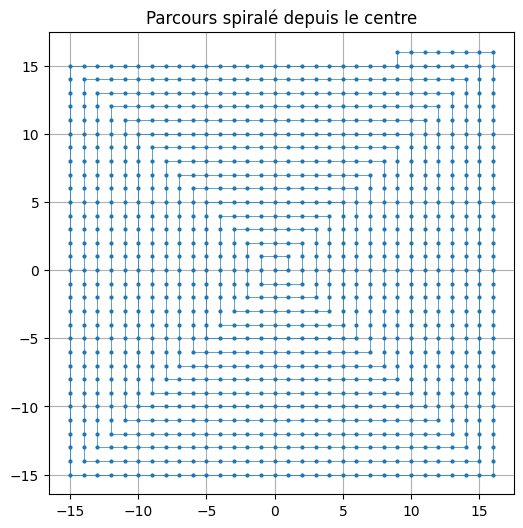

In [122]:
import matplotlib.pyplot as plt

def spiral_coords(n_steps):
    """
    Génère les coordonnées d'un parcours en spirale à partir du centre (0,0).
    Sens horaire : droite, bas, gauche, haut.
    """
    x = y = 0
    dx, dy = 1, 0
    steps = 1
    spiral = [(x, y)]

    while len(spiral) < n_steps:
        for _ in range(2):  # deux fois à chaque 'couche'
            for _ in range(steps):
                x += dx
                y += dy
                spiral.append((x, y))
                if len(spiral) >= n_steps:
                    break
            dx, dy = -dy, dx  # rotation horaire
        steps += 1
    return spiral

# Exemple avec 1000 points
spiral = spiral_coords(1000)

# Affichage
x_coords, y_coords = zip(*spiral)
plt.figure(figsize=(6, 6))
plt.plot(x_coords, y_coords, lw=0.5, marker='o', markersize=2)
plt.title("Parcours spiralé depuis le centre")
plt.axis('equal')
plt.grid(True)
plt.show()
